# Myanmar (MM) Datasets Directory — Exploratory Data Analysis

This notebook provides a comprehensive overview and analysis of the Myanmar dataset directory sourced from [mmdatasetdirectories](https://mmdatadirectories.lovable.app).

**Dataset covers 9 categories:**
- NLP & Language
- Humanitarian
- Geospatial
- Economic
- Health
- Agriculture
- Transport
- Media
- Education

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from collections import Counter

# Load the dataset
df = pd.read_csv('mm_datasets_all.csv')

print(f'Total datasets: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head()

Total datasets: 94
Columns: ['id', 'title', 'category', 'description', 'source', 'format', 'license', 'updated', 'url', 'tags']


,id,title,category,description,source,format,license,updated,url,tags
0,nlp-001,Crowdsourced High-Quality Burmese Speech Datas...,nlp,Crowdsourced high-quality Burmese speech datas...,OpenSLR,"Audio, Text",CC BY-SA 4.0,2024-01,https://huggingface.co/datasets/google/fleurs,"ASR, Speech, Burmese"
1,nlp-002,BloomSpeech Myanmar,nlp,BloomSpeech multilingual audio dataset — Myanm...,BigScience,Audio,CC BY 4.0,2024-01,https://huggingface.co/datasets/bigscience/blo...,"ASR, Speech, Burmese"
2,nlp-003,Google Fleurs Myanmar,nlp,Google FLEURS Myanmar language subset.,Google,"Audio, Text",CC BY 4.0,2024-01,https://huggingface.co/datasets/google/fleurs,"ASR, Speech, Burmese"
3,nlp-004,MIG Burmese Audio,nlp,Burmese audio dataset from MIG for ASR training.,MIG,Audio,License Unknown,2024-01,NaN,"ASR, Speech, Burmese"
4,nlp-005,Asian Language Treebank (ALT) — Myanmar,nlp,Parallel corpus supporting translation between...,NICT,Text,CC BY 4.0,2024-01,https://huggingface.co/datasets/alt,"Machine Translation, NLP, Burmese, Multilingual"


## 1. Basic Statistics

In [3]:
print('=== Dataset Summary ===')
print(f"Total datasets: {len(df)}")
print(f"Categories: {df['category'].nunique()}")
print(f"Unique sources: {df['source'].nunique()}")
print(f"Datasets with URLs: {df['url'].notna().sum() - (df['url'] == '').sum()}")

print('\n=== Datasets per Category ===')
print(df['category'].value_counts().to_string())

=== Dataset Summary ===
Total datasets: 94
Categories: 9
Unique sources: 48
Datasets with URLs: 68

=== Datasets per Category ===
category
nlp             37
humanitarian    30
media            8
economic         7
geo              3
education        3
health           2
agri             2
transport        2


## 2. Category Distribution

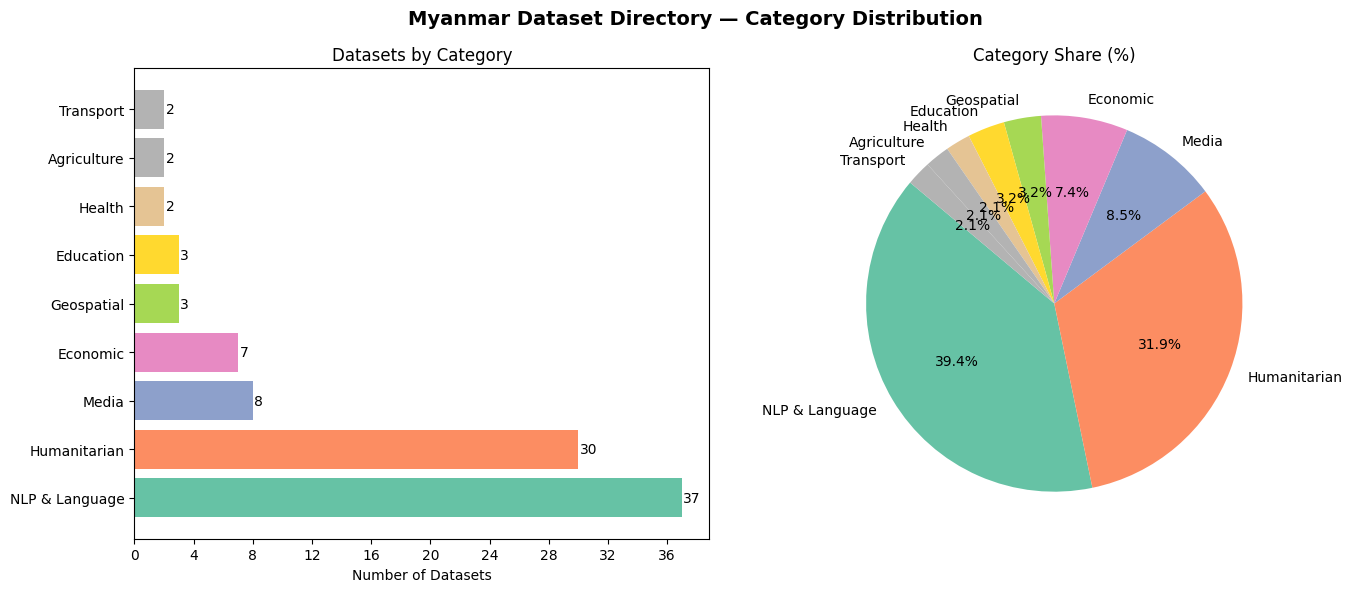

Saved: category_distribution.png


In [4]:
cat_counts = df['category'].value_counts()

category_labels = {
    'nlp': 'NLP & Language',
    'humanitarian': 'Humanitarian',
    'geo': 'Geospatial',
    'economic': 'Economic',
    'health': 'Health',
    'agri': 'Agriculture',
    'transport': 'Transport',
    'media': 'Media',
    'education': 'Education'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
colors = plt.cm.Set2(np.linspace(0, 1, len(cat_counts)))
axes[0].barh([category_labels.get(c, c) for c in cat_counts.index], cat_counts.values, color=colors)
axes[0].set_xlabel('Number of Datasets')
axes[0].set_title('Datasets by Category')
axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
for i, v in enumerate(cat_counts.values):
    axes[0].text(v + 0.1, i, str(v), va='center', fontsize=10)

# Pie chart
axes[1].pie(cat_counts.values,
            labels=[category_labels.get(c, c) for c in cat_counts.index],
            autopct='%1.1f%%', startangle=140, colors=colors)
axes[1].set_title('Category Share (%)')

plt.suptitle('Myanmar Dataset Directory — Category Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: category_distribution.png')

## 3. License Analysis

/var/folders/rp/t1jl7bd915v7bgwrnmxw3tqc0000gn/T/ipykernel_76570/2037708862.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(lic_counts.index, rotation=30, ha='right')


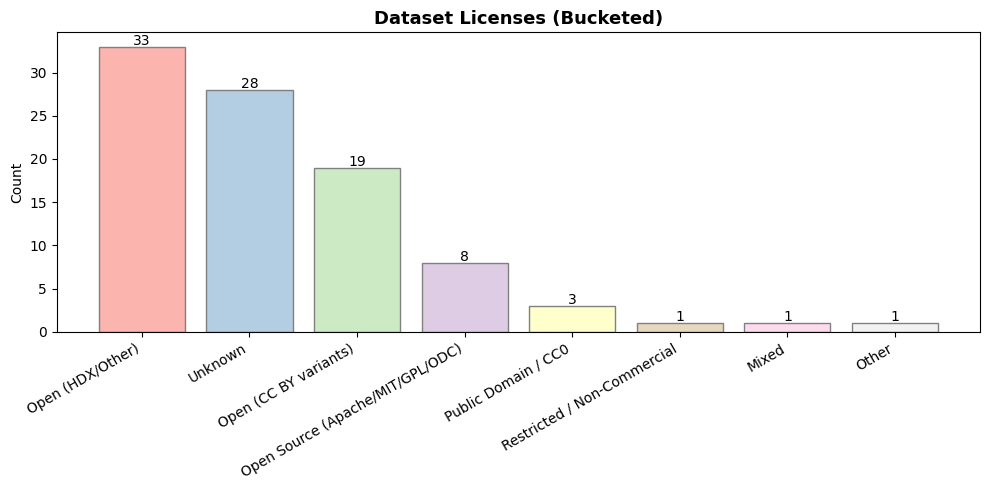

Saved: license_distribution.png


In [5]:
# Normalize licenses into open/restricted buckets
def bucket_license(lic):
    if pd.isna(lic) or 'unknown' in str(lic).lower():
        return 'Unknown'
    lic_l = str(lic).lower()
    if 'cc0' in lic_l or 'public domain' in lic_l:
        return 'Public Domain / CC0'
    if 'cc by' in lic_l and 'nc' not in lic_l:
        return 'Open (CC BY variants)'
    if 'apache' in lic_l or 'mit' in lic_l or 'gpl' in lic_l or 'odc' in lic_l:
        return 'Open Source (Apache/MIT/GPL/ODC)'
    if 'open' in lic_l or 'hdx' in lic_l:
        return 'Open (HDX/Other)'
    if 'nc' in lic_l or 'registration' in lic_l:
        return 'Restricted / Non-Commercial'
    if 'mixed' in lic_l:
        return 'Mixed'
    return 'Other'

df['license_bucket'] = df['license'].apply(bucket_license)
lic_counts = df['license_bucket'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.Pastel1(np.linspace(0, 1, len(lic_counts)))
bars = ax.bar(lic_counts.index, lic_counts.values, color=colors, edgecolor='grey')
ax.set_title('Dataset Licenses (Bucketed)', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xticklabels(lic_counts.index, rotation=30, ha='right')
for bar, val in zip(bars, lic_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('license_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: license_distribution.png')

## 4. File Format Analysis

/var/folders/rp/t1jl7bd915v7bgwrnmxw3tqc0000gn/T/ipykernel_76570/1609029981.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(fmt_series.index, rotation=30, ha='right')


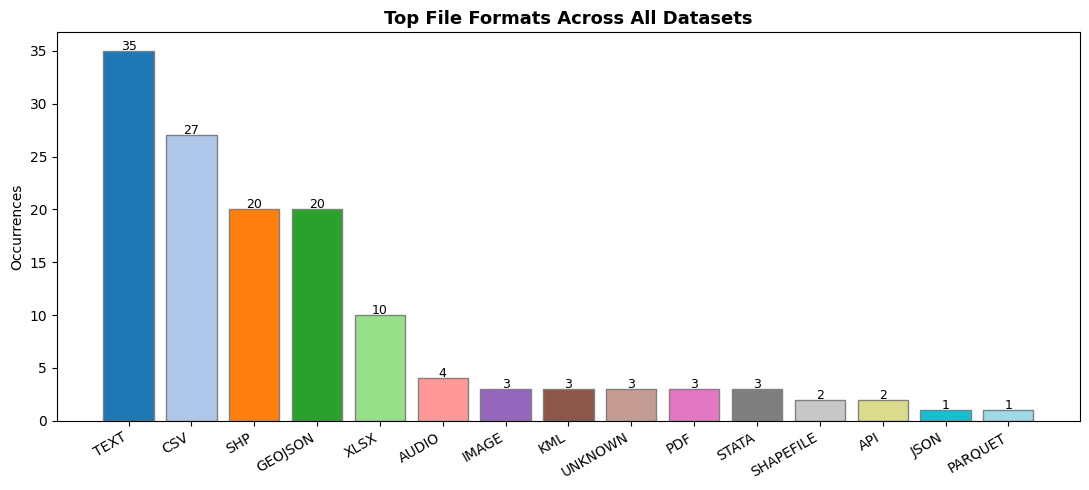

Saved: format_distribution.png


In [6]:
# Explode multi-format entries
all_formats = []
for fmt_str in df['format'].dropna():
    for f in str(fmt_str).split(','):
        all_formats.append(f.strip().upper())

fmt_counts = Counter(all_formats)
fmt_series = pd.Series(fmt_counts).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 5))
colors = plt.cm.tab20(np.linspace(0, 1, len(fmt_series)))
ax.bar(fmt_series.index, fmt_series.values, color=colors, edgecolor='grey')
ax.set_title('Top File Formats Across All Datasets', fontsize=13, fontweight='bold')
ax.set_ylabel('Occurrences')
ax.set_xticklabels(fmt_series.index, rotation=30, ha='right')
for i, (_, v) in enumerate(fmt_series.items()):
    ax.text(i, v + 0.1, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('format_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: format_distribution.png')

## 5. Top Data Sources

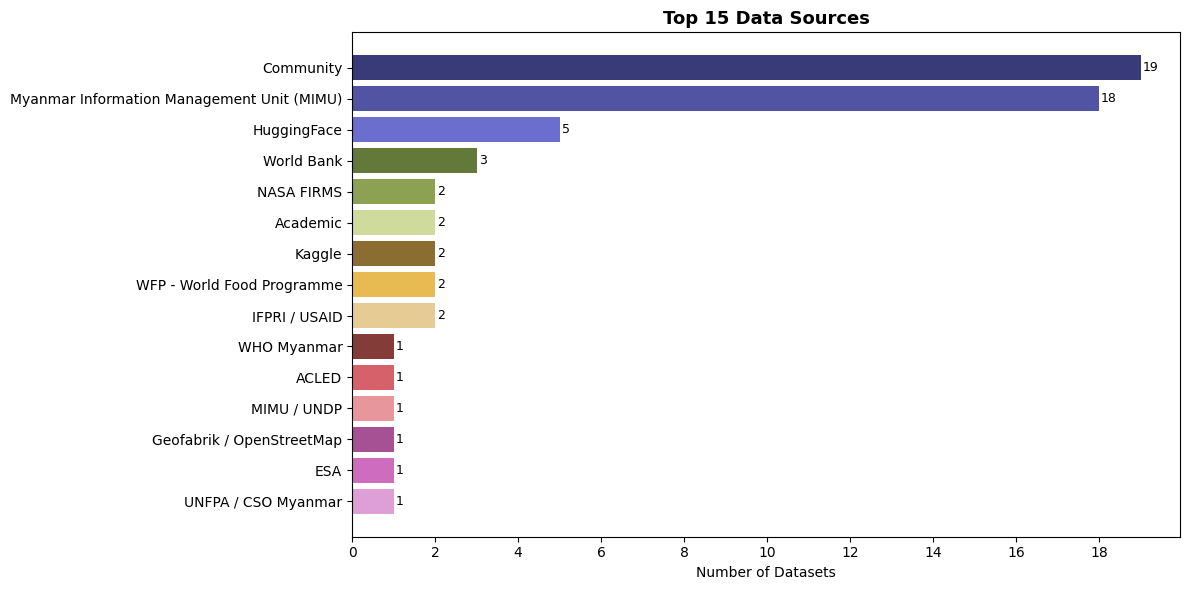

Saved: top_sources.png


In [7]:
top_sources = df['source'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab20b(np.linspace(0, 1, len(top_sources)))
ax.barh(top_sources.index[::-1], top_sources.values[::-1], color=colors[::-1])
ax.set_title('Top 15 Data Sources', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Datasets')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
for i, v in enumerate(top_sources.values[::-1]):
    ax.text(v + 0.05, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_sources.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: top_sources.png')

## 6. Tags / Topic Analysis

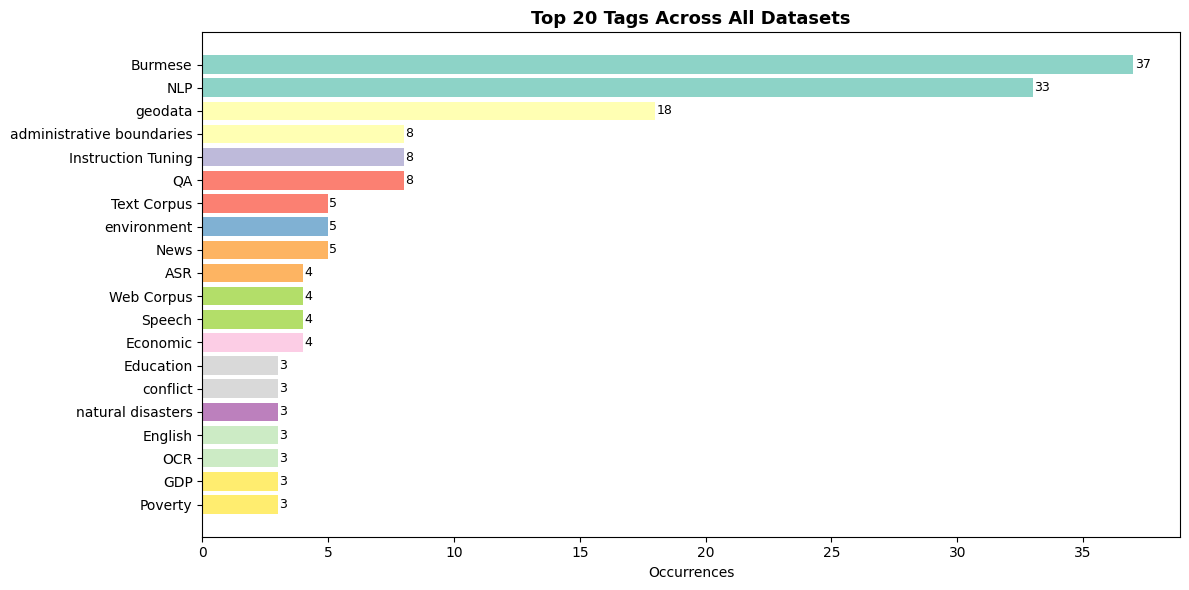

Saved: top_tags.png


In [8]:
all_tags = []
for tag_str in df['tags'].dropna():
    for t in str(tag_str).split(','):
        cleaned = t.strip()
        if cleaned:
            all_tags.append(cleaned)

tag_counts = Counter(all_tags)
top_tags = pd.Series(tag_counts).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(top_tags)))
ax.barh(top_tags.index[::-1], top_tags.values[::-1], color=colors[::-1])
ax.set_title('Top 20 Tags Across All Datasets', fontsize=13, fontweight='bold')
ax.set_xlabel('Occurrences')
for i, v in enumerate(top_tags.values[::-1]):
    ax.text(v + 0.05, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_tags.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: top_tags.png')

## 7. Update Recency Analysis

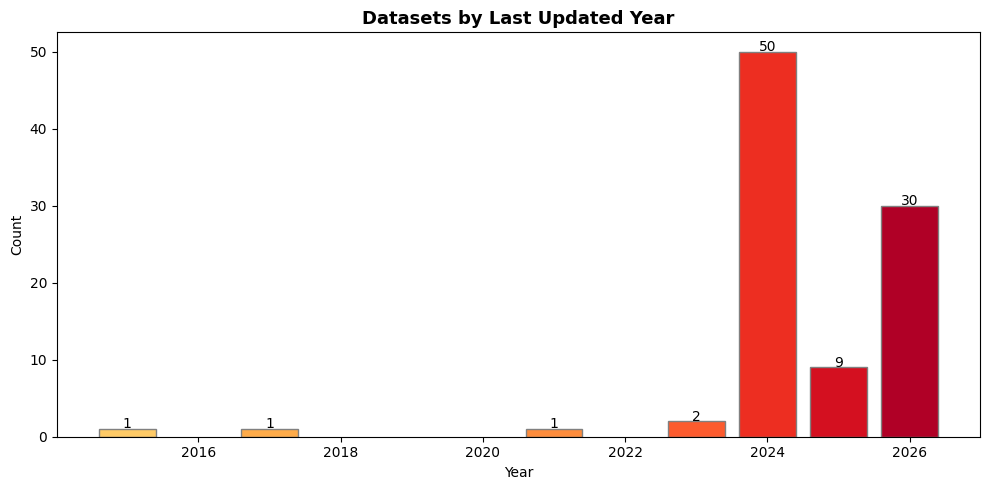

Saved: update_year_distribution.png


In [9]:
# Parse year from updated field (format: YYYY-MM)
df['update_year'] = df['updated'].str[:4].astype(float)

year_counts = df['update_year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(year_counts.index.astype(int), year_counts.values,
       color=plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(year_counts))), edgecolor='grey')
ax.set_title('Datasets by Last Updated Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
for i, (year, count) in enumerate(year_counts.items()):
    ax.text(int(year), count + 0.1, str(count), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('update_year_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: update_year_distribution.png')

## 8. Heatmap: Category × License

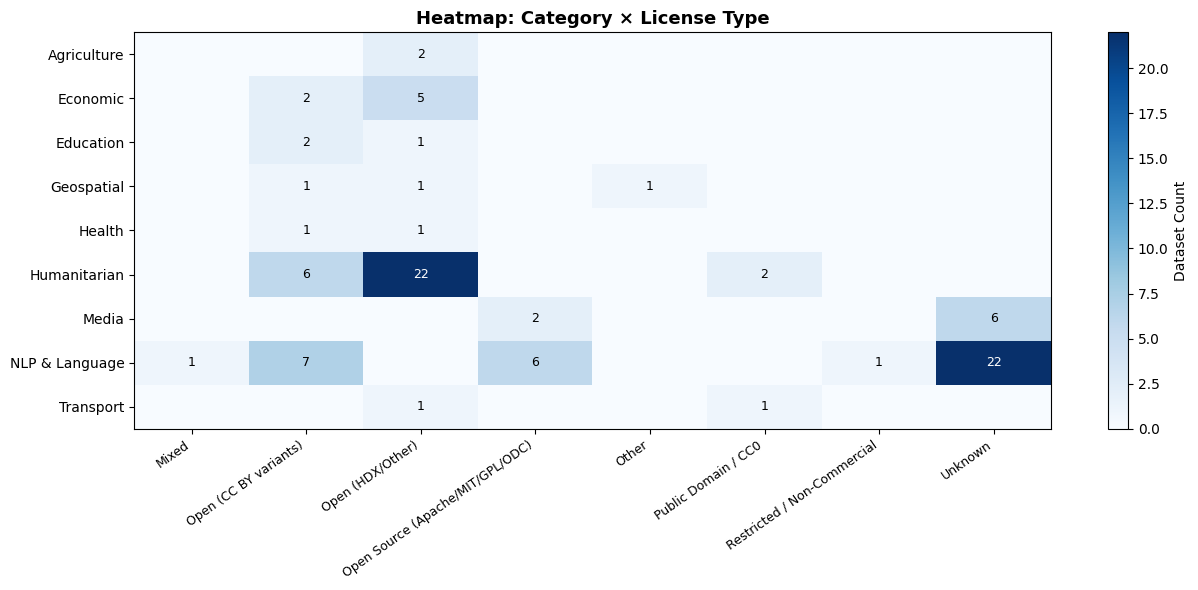

Saved: category_license_heatmap.png


In [10]:
pivot = pd.crosstab(df['category'], df['license_bucket'])

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(pivot.values, cmap='Blues', aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([category_labels.get(c, c) for c in pivot.index], fontsize=10)
ax.set_title('Heatmap: Category × License Type', fontsize=13, fontweight='bold')

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if val > 0:
            ax.text(j, i, str(val), ha='center', va='center',
                    color='white' if val > pivot.values.max()*0.5 else 'black', fontsize=9)

plt.colorbar(im, ax=ax, label='Dataset Count')
plt.tight_layout()
plt.savefig('category_license_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: category_license_heatmap.png')

## 9. URL Coverage

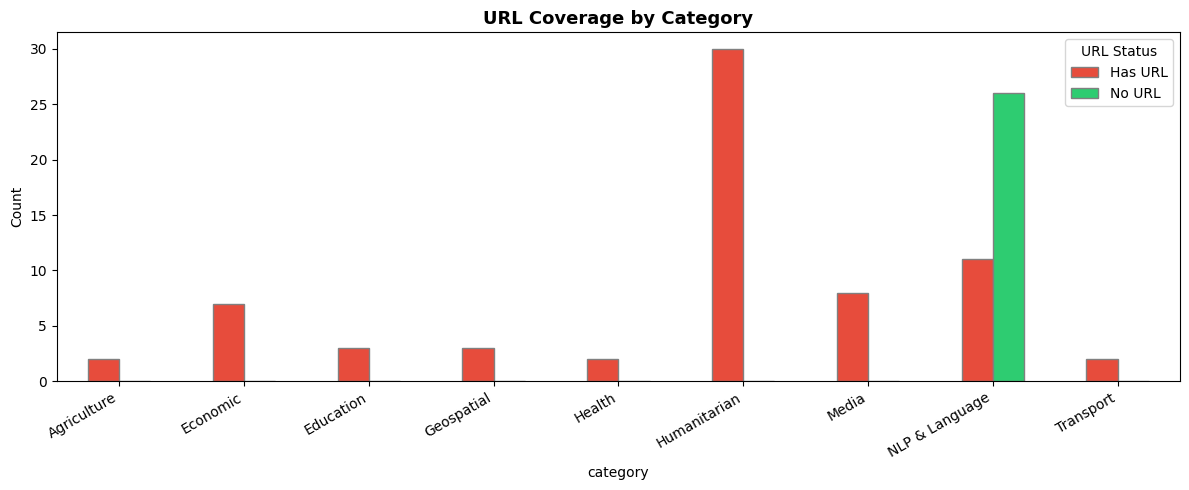

Saved: url_coverage.png

Overall URL coverage: 72.3% have a URL


In [11]:
df['has_url'] = df['url'].apply(lambda x: 'Has URL' if str(x).startswith('http') else 'No URL')

url_by_cat = df.groupby(['category','has_url']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
url_by_cat.plot(kind='bar', ax=ax,
               color=['#e74c3c','#2ecc71'], edgecolor='grey')
ax.set_xticklabels([category_labels.get(c, c) for c in url_by_cat.index], rotation=30, ha='right')
ax.set_title('URL Coverage by Category', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.legend(title='URL Status')
plt.tight_layout()
plt.savefig('url_coverage.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: url_coverage.png')

pct = df['has_url'].value_counts(normalize=True)*100
print(f"\nOverall URL coverage: {pct.get('Has URL', 0):.1f}% have a URL")